## Лабораторна робота №1 “Linear Regression”
#### Мета: навчитись реалізовувати лінійну регресію та градієнтний спуск.
#### Завдання:

1. Викачати дані з https://drive.google.com/drive/folders/17Xwk2quPb1gFmjG3KVIoZqChrWdcZ8XS?usp=sharing

In [2]:
import numpy as np
import matplotlib.pyplot as plt

train_data = np.loadtxt('lab_1_train.csv', delimiter=',', skiprows=1)
test_data = np.loadtxt('lab_1_test.csv', delimiter=',', skiprows=1)

train_X = train_data[:, 1]
train_y = train_data[:, 2]

test_X = test_data[:, 1]
test_y = test_data[:, 2]

2. Реалізувати лінійну регресію, яка за допомогою даних з колонки “x” прогнозує значення в колонці “y” (перша колонка у файлах - просто індекс, не ознака, не потрібно її використовувати). Тренування алгоритму повинно відбуватись лише на даних з train датасету. Test датасет слугує для перевірки якості вже натренованої моделі.

    a) Візуалізувати дані з lab1_train.csv.

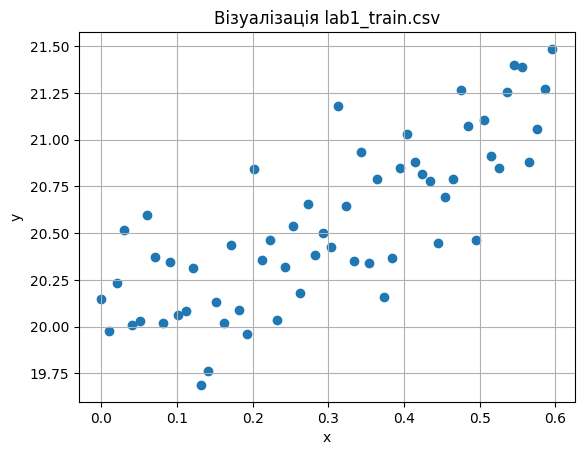

In [3]:
plt.scatter(train_X, train_y)
plt.title('Візуалізація lab1_train.csv')
plt.xlabel('x'); plt.ylabel('y')
plt.grid()
plt.show()

    b) Після кожної епохи виводити поточні значення ваг та функції втрат. Використовувати Mean Squared Error як функцію втрат.

In [6]:
b0 = b1 = 0.0
alpha = 0.01 
J_eps = 0.000001
prev_J = float('inf')
m = len(train_X)
epoch = 0 

print("Початок градієнтного спуску:")
while True:
    pred_y = b0 + b1 * train_X
    
    e =  pred_y - train_y
    J = (1 / (2 * m)) * np.sum(e ** 2)
    
    if epoch % 100 == 0: print(f"Епоха {epoch}: b0 = {b0:.5f}, b1 = {b1:.5f}, J = {J:.5f}")
    

    if abs(prev_J - J) < J_eps:
        print(f"Умова збіжності виконана на епосі {epoch}")
        print(f"Епоха {epoch}: b0 = {b0:.5f}, b1 = {b1:.5f}, J = {J:.5f}")
        break
        
    prev_J = J
    
    dJ_db0 = (1 / m) * np.sum(e)
    dJ_db1 = (1 / m) * np.sum(e * train_X)
    
    b0 = b0 - alpha * dJ_db0
    b1 = b1 - alpha * dJ_db1
    
    epoch += 1

Початок градієнтного спуску:
Епоха 0: b0 = 0.00000, b1 = 0.00000, J = 211.23870
Епоха 100: b0 = 12.55727, b1 = 3.73526, J = 23.74587
Епоха 200: b0 = 16.76879, b1 = 4.91508, J = 2.85078
Епоха 300: b0 = 18.19432, b1 = 5.24386, J = 0.51380
Епоха 400: b0 = 18.68947, b1 = 5.29040, J = 0.24454
Епоха 500: b0 = 18.87357, b1 = 5.24449, J = 0.20610
Епоха 600: b0 = 18.95333, b1 = 5.16942, J = 0.19384
Епоха 700: b0 = 18.99776, b1 = 5.08628, J = 0.18492
Епоха 800: b0 = 19.02990, b1 = 5.00204, J = 0.17679
Епоха 900: b0 = 19.05747, b1 = 4.91901, J = 0.16913
Епоха 1000: b0 = 19.08304, b1 = 4.83789, J = 0.16190
Епоха 1100: b0 = 19.10750, b1 = 4.75889, J = 0.15506
Епоха 1200: b0 = 19.13114, b1 = 4.68203, J = 0.14860
Епоха 1300: b0 = 19.15408, b1 = 4.60728, J = 0.14248
Епоха 1400: b0 = 19.17637, b1 = 4.53460, J = 0.13670
Епоха 1500: b0 = 19.19804, b1 = 4.46392, J = 0.13124
Епоха 1600: b0 = 19.21911, b1 = 4.39520, J = 0.12607
Епоха 1700: b0 = 19.23960, b1 = 4.32838, J = 0.12119
Епоха 1800: b0 = 19.25952, 

c) Після того, як градієнтний спуск зійшовся, порахувати функцію втрат на тестових даних з lab1_test.csv.

In [ ]:
pred_test_y = b0 + b1 * test_X
test_J = (1 / (2 * m)) * np.sum((test_y - pred_test_y) ** 2)
print(f"J на lab1_test.csv: {test_J:.5f}")

d) Візуалізувати на одному графіку дані з lab1_train.csv,  lab1_test.csv та лінію, до якої зійшовся розв’язок.

In [ ]:
plt.scatter(train_X, train_y, color='blue', label='Train')
plt.scatter(test_X, test_y, color='red', label='Test')

x_min = min(np.min(train_X), np.min(test_X))
x_max = max(np.max(train_X), np.max(test_X))
x_line = np.array([x_min, x_max])
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, label='Лінія регресії')
plt.title('Лінійна регресія за градієнтним спуском')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

Формулою Оптимального Визначення Ваги

In [ ]:
w1 = (np.sum(train_X * train_y) - (1 / n) * np.sum(train_X) * np.sum(train_y)) / (np.sum(train_X ** 2) - (1 / n) * (np.sum(train_X) ** 2))
w0 = np.mean(train_y) - w1 * np.mean(train_X)

print(f"w0 = {w0:.5f}, w1 = {w1:.5f}")

Порівняння оптимального і градієнтного методів визначення вагів

In [ ]:
plt.scatter(train_X, train_y, color='blue', label='Train')
plt.scatter(test_X, test_y, color='red', label='Test')
y_line_opt = w0 + w1 * x_line

plt.plot(x_line, y_line_gr, label='Лінія регресії')
plt.plot(x_line, y_line_opt, color='black', label='Лінія регресії оптим')
plt.title('Порівняння оптимального і градієнтного методів визначення вагів')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

## Висновок:

У ході виконання лабораторної роботи було успішно реалізовано алгоритм лінійної регресії. Під час роботи було налагоджено процес обчислення функції втрат та ітеративне оновлення ваг моделі, а також практично доведено важливість правильного підбору кроку alpha для успішного сходження алгоритму до глобального мінімуму. Обчислення похибки на тестовій вибірці та підсумкова візуалізація підтвердили, що побудована модель не лише мінімізувала помилку на тренувальних даних, але й здатна точно прогнозувати значення на нових, невідомих алгоритму даних.